In [1]:
import pandas as pd
import numpy as np

In [7]:
data = pd.read_csv('data_vader.csv')

In [8]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment_vader
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,positive
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393579 entries, 0 to 393578
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      393579 non-null  int64 
 1   ProductId               393579 non-null  object
 2   UserId                  393579 non-null  object
 3   ProfileName             393563 non-null  object
 4   HelpfulnessNumerator    393579 non-null  int64 
 5   HelpfulnessDenominator  393579 non-null  int64 
 6   Score                   393579 non-null  int64 
 7   Time                    393579 non-null  int64 
 8   Summary                 393576 non-null  object
 9   Text                    393579 non-null  object
 10  sentiment_vader         393579 non-null  object
dtypes: int64(5), object(6)
memory usage: 33.0+ MB


In [10]:
data.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,393579.000000,393579.000000,393579.000000,393579.000000,3.935790e+05
mean,261289.782964,1.733535,2.203708,4.179260,1.296478e+09
std,167028.823852,6.873517,7.535616,1.311983,4.836848e+07
min,1.000000,0.000000,0.000000,1.000000,9.393408e+08
25%,112561.500000,0.000000,0.000000,4.000000,1.271462e+09
50%,248705.000000,0.000000,1.000000,5.000000,1.311638e+09
75%,407098.500000,2.000000,2.000000,5.000000,1.332979e+09
max,568454.000000,866.000000,923.000000,5.000000,1.351210e+09


In [11]:
data1 = data.drop_duplicates(subset=['Text'])
data1 = data1.reset_index(drop=True)
data1.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment_vader
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,positive
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive


In [12]:
data1['sentiment_vader'].value_counts()

,count
sentiment_vader,
positive,346329
negative,38872
neutral,8378


In [13]:
positive_sample = data1[data1['sentiment_vader'] == 'positive'].sample(n=8000, random_state=42)
negative_sample = data1[data1['sentiment_vader'] == 'negative'].sample(n=8000, random_state=42)
neutral_sample = data1[data1['sentiment_vader'] == 'neutral'].sample(n=8000, random_state=42)

In [14]:
balanced_data = pd.concat([positive_sample, negative_sample, neutral_sample])

In [15]:
balanced_data_vader = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
print(balanced_data_vader['sentiment_vader'].value_counts())

sentiment_vader
positive    8000
neutral     8000
negative    8000
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
balanced_data_vader['sentiment_encoded'] = label_encoder.fit_transform(balanced_data_vader['sentiment_vader'])
data['sentiment_encoded'] = label_encoder.fit_transform(data['sentiment_vader'])

In [17]:
balanced_data_vader.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,sentiment_vader,sentiment_encoded
0,236899,B001OQXEHK,A2PE65WEM7I1P4,SSS,0,2,1,1340841600,"disgusting, don't buy it",This litter is horrible! It DOES NOT lock in o...,positive,2
1,541448,B0037YP75E,A3DRGEYPSAP1VE,KenHoov,0,0,4,1292284800,Great product!,The product was delivered in a timely manner a...,neutral,1
2,176521,B004DIZZA0,A3LT12H2F7A5PJ,Deborah,0,1,1,1346198400,Have to agree this is not cranberry juice,"Reading the label it says this is ""27% cranber...",neutral,1
3,240782,B000NBQUNW,A2BCFB87R9BWCW,"belleterre ""beautiful earth""",0,0,5,1344556800,IT WORKS!,This is a product that really works. My choles...,neutral,1
4,60038,B000F013Q0,A2XXKQ4TH4MLC7,"Cristal J. Hannah ""golden girl""",0,0,5,1329696000,MM Good!,U can taste the lemon in this blend. I have t...,neutral,1


In [18]:
from sklearn.model_selection import train_test_split

def data_split(data):
  X_train, X_test, y_train, y_test = train_test_split(data['Text'], data['sentiment_encoded'], test_size=0.2, random_state=42)
  return X_train, X_test, y_train, y_test

In [19]:
train_sentences, test_sentences, train_labels, test_labels = data_split(balanced_data_vader)
print(f'Total data for training : {train_sentences.nunique()}')
print(f'Total data for testing : {test_sentences.nunique()}')
print(f"""Total sentiments counts for train data :
     {train_labels.value_counts()}""")
print(f"""Total sentiments counts for test data :
     {test_labels.value_counts()}""")

Total data for training : 19200
Total data for testing : 4800
Total sentiments counts for train data :
     sentiment_encoded
0    6419
1    6399
2    6382
Name: count, dtype: int64
Total sentiments counts for test data :
     sentiment_encoded
2    1618
1    1601
0    1581
Name: count, dtype: int64


In [20]:
import tensorflow
import keras
#from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

vocab_size = 17000
oov_tok = ''
embedding_dim = 64
max_length = 296
padding_type='post'
trunc_type='post'

tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index

train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences, padding='post', maxlen=max_length)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding='post', maxlen=max_length)

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential([
    Embedding(vocab_size+1, embedding_dim, input_length=max_length, embeddings_regularizer = regularizers.l2(0.0005)),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(24, activation='relu', kernel_regularizer = regularizers.l2(0.0005), bias_regularizer = regularizers.l2(0.0005)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.001),bias_regularizer=regularizers.l2(0.001),)
])

model.compile(loss='sparse_categorical_crossentropy',optimizer='Nadam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

In [23]:
history = model.fit(train_padded, train_labels, epochs=15, validation_split=0.2, batch_size=128, callbacks=callbacks)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3527 - loss: 1.9976

120/120 ━━━━━━━━━━━━━━━━━━━━ 461s 4s/step - accuracy: 0.3528 - loss: 1.9955 - val_accuracy: 0.3552 - val_loss: 1.2496
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4793 - loss: 1.2234

120/120 ━━━━━━━━━━━━━━━━━━━━ 516s 4s/step - accuracy: 0.4795 - loss: 1.2229 - val_accuracy: 0.5172 - val_loss: 1.0889
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 494s 4s/step - accuracy: 0.5293 - loss: 1.0671 - val_accuracy: 0.3279 - val_loss: 1.8981
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step - accuracy: 0.6174 - loss: 0.8965 - val_accuracy: 0.4201 - val_loss: 1.5167
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 513s 4s/step - accuracy: 0.7073 - loss: 0.8038 - val_accuracy: 0.3719 - val_loss: 2.3279
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7694 - loss: 0.6939

120/120 ━━━━━━━━━━━━━━━━━━━━ 499s 4s/step - accuracy: 0.7693 - loss: 0.6940 - val_accuracy: 0.6784 - val_loss: 0.8948
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.8119 - loss: 0.6451 - val_accuracy: 0.6698 - val_loss: 0.9415
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 462s 4s/step - accuracy: 0.8289 - loss: 0.6056 - val_accuracy: 0.6685 - val_loss: 0.9719
Epoch 9/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - accuracy: 0.8440 - loss: 0.5786 - val_accuracy: 0.5734 - val_loss: 1.1500
Epoch 10/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 506s 4s/step - accuracy: 0.8590 - loss: 0.5425 - val_accuracy: 0.6750 - val_loss: 0.9717
Epoch 11/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 495s 4s/step - accuracy: 0.8718 - loss: 0.5278 - val_accuracy: 0.6714 - val_loss: 1.2029


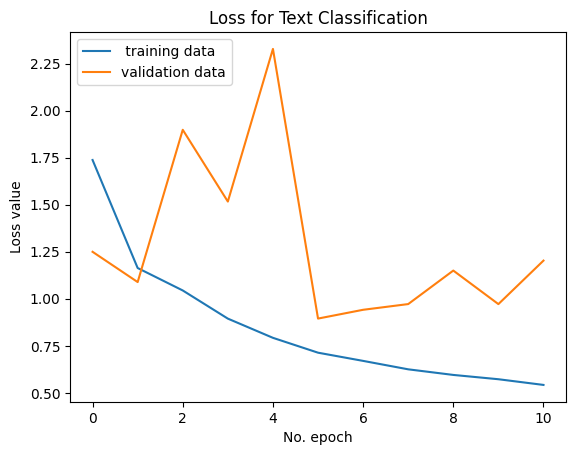

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label=' training data')
plt.plot(history.history['val_loss'], label='validation data')
plt.title('Loss for Text Classification')
plt.ylabel('Loss value')
plt.xlabel('No. epoch')
plt.legend(loc="upper left")
plt.show()

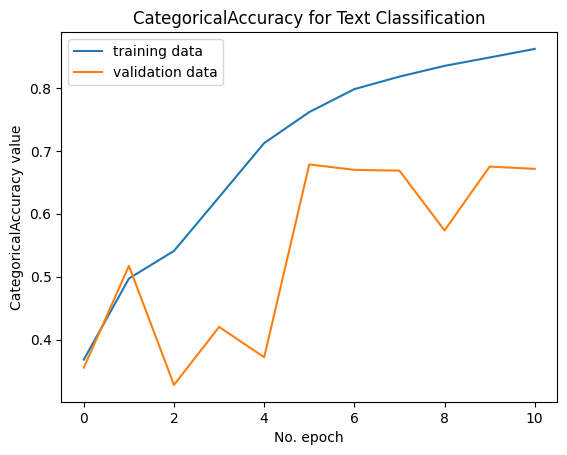

In [25]:
plt.plot(history.history['accuracy'], label='training data')
plt.plot(history.history['val_accuracy'], label='validation data')
plt.title('CategoricalAccuracy for Text Classification')
plt.ylabel('CategoricalAccuracy value')
plt.xlabel('No. epoch')
plt.legend(loc="upper left")
plt.show()

In [26]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')

In [27]:
print("Generate predictions for all samples")
predictions = best_model.predict(test_padded)
print(predictions)
predict_results = predictions.argmax(axis=1)

Generate predictions for all samples
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 435ms/step
[[0.08237209 0.91063005 0.00699781]
 [0.77495927 0.17919946 0.0458412 ]
 [0.8081377  0.13914262 0.05271969]
 ...
 [0.90276134 0.05617836 0.04106027]
 [0.71351546 0.2353946  0.0510901 ]
 [0.5569683  0.26513892 0.17789282]]


In [28]:
print(predict_results.shape)
if len(predict_results.shape) == 1:
    y_pred = predict_results
else:
    y_pred = np.argmax(predict_results, axis=1)

print(y_pred)

(4800,)
[1 0 0 ... 0 0 0]


In [29]:
from sklearn.metrics import accuracy_score
y_test=test_labels
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 68.46%


Text(50.722222222222214, 0.5, 'y_pred')

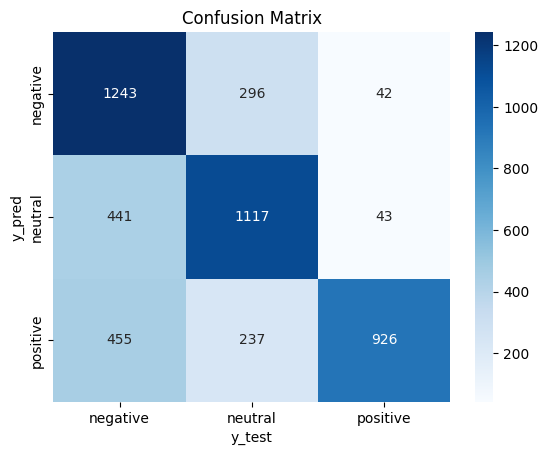

In [30]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)
ax=sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
ax.set_title('Confusion Matrix')
ax.set_xlabel('y_test')
ax.set_ylabel('y_pred')

In [31]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    negative       0.58      0.79      0.67      1581
     neutral       0.68      0.70      0.69      1601
    positive       0.92      0.57      0.70      1618

    accuracy                           0.68      4800
   macro avg       0.72      0.69      0.69      4800
weighted avg       0.73      0.68      0.69      4800

